In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#carregar dados
df = pd.DataFrame(pd.read_csv('dados_2025.csv'))
# Limpeza de dados 
#Arrumar valor de transação
df['valorTransacao'] = pd.to_numeric(df['valorTransacao']. 
                        str.replace('.', ''). #retira o . da casa de milhares
                        str.replace(',', '.'). #substitui , de centavos para .
                        str.replace('- ', '-') #substitui
)
df['dataTransacao'] = pd.to_datetime(df['dataTransacao']. 
                        str.replace('Sem informação', '01/01/2025'),
                        dayfirst=True
)
df = df[df['dataTransacao'].dt.year == 2025]
df = df.drop_duplicates()

In [4]:
#Features
portadores_stats = df.groupby('portador.nome').agg(
    valor_total=('valorTransacao', 'sum'),
    num_transacoes=('valorTransacao', 'count'),
    valor_medio=('valorTransacao', 'mean'),
    diversidade_estabelecimentos=('estabelecimento.nome', 'nunique'),
    diversidade_orgao=("unidadeGestora.orgaoMaximo.nome", 'nunique')
).reset_index()


In [5]:
#Normalização
features = ['valor_total', 'num_transacoes', 'valor_medio', 'diversidade_estabelecimentos', 'diversidade_orgao']
X = portadores_stats[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
portadores_stats['cluster'] = kmeans.fit_predict(X_scaled)

In [6]:
#Caracterização dos Clusters
cluster_summary = portadores_stats.groupby('cluster')[features].mean().round(2)
cluster_counts = portadores_stats['cluster'].value_counts().sort_index()
cluster_summary['contagem_portadores'] = cluster_counts

In [7]:
print("--- Resumo dos Perfis (Clusters) Identificados ---")
print(cluster_summary)

--- Resumo dos Perfis (Clusters) Identificados ---
         valor_total  num_transacoes  valor_medio  \
cluster                                             
0           43203.40           11.58      7075.71   
1          417289.41           27.63     70486.97   
2        32700647.39        32530.00      1005.25   
3         4032331.36            5.08   1056164.57   
4           46048.07           60.20       728.13   

         diversidade_estabelecimentos  diversidade_orgao  contagem_portadores  
cluster                                                                        
0                                5.69               1.00                 5528  
1                                6.80               2.07                   30  
2                                1.00               4.00                    1  
3                                2.08               1.08                   12  
4                               31.67               1.00                  763  


perfil_uso
0 - Consumo Padrão Adm          5528
4 - Possíveis Viagens            763
1 - Pagamentos de Alto Valor      30
3 - Grandes Contratos             12
2 - Pagamentos Sigilosos           1
Name: count, dtype: int64


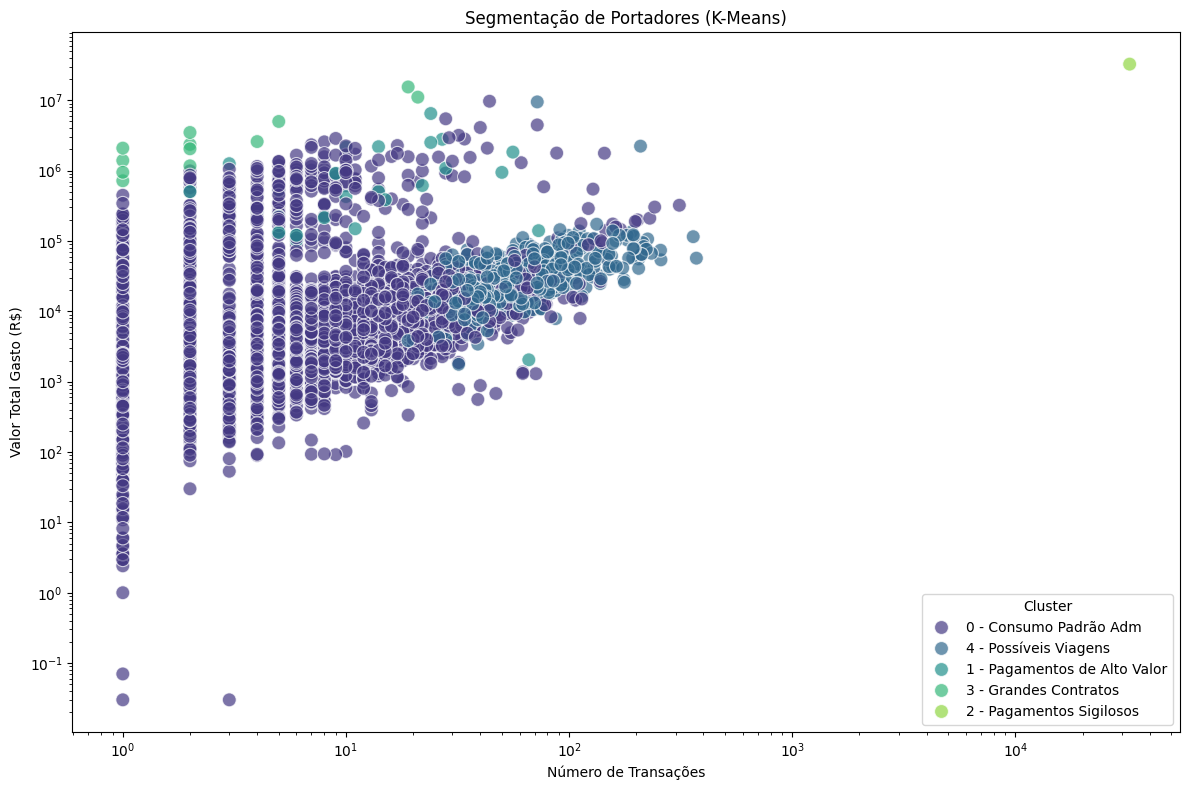

In [8]:
mapa_perfis = {
    0: '0 - Consumo Padrão Adm',
    1: '1 - Pagamentos de Alto Valor',
    2: '2 - Pagamentos Sigilosos',
    3: '3 - Grandes Contratos',
    4: '4 - Possíveis Viagens'
}

portadores_stats['perfil_uso'] = portadores_stats['cluster'].map(mapa_perfis)

resumo_perfis = portadores_stats['perfil_uso'].value_counts()
print(resumo_perfis)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=portadores_stats, x='num_transacoes', y='valor_total', hue='perfil_uso', palette='viridis', s=100, alpha=0.7)
plt.title('Segmentação de Portadores (K-Means)')
plt.xlabel('Número de Transações')
plt.ylabel('Valor Total Gasto (R$)')
plt.yscale('log') 
plt.xscale('log')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [9]:
df_completo = df.merge(
    portadores_stats[['portador.nome', 'cluster', 'perfil_uso']],
    on='portador.nome',
    how='left'
)

In [ ]:
for cluster_id, perfil_nome in mapa_perfis.items():
    subset = df_completo[df_completo['cluster'] == cluster_id]
    
    nome_arquivo = perfil_nome.replace(' ', '_').replace('/', '-')
    caminho = f'cluster_{nome_arquivo}.csv'
    
    subset.to_csv(caminho, index=False, encoding='utf-8-sig')
    print(f"Cluster {cluster_id} — {len(subset)} transações salvas em: {caminho}")


Cluster 0 — 64008 transações salvas em: cluster_0_-_Consumo_Padrão_Adm.csv
Cluster 1 — 829 transações salvas em: cluster_1_-_Pagamentos_de_Alto_Valor.csv
Cluster 2 — 32530 transações salvas em: cluster_2_-_Pagamentos_Sigilosos.csv
Cluster 3 — 61 transações salvas em: cluster_3_-_Grandes_Contratos.csv
Cluster 4 — 45933 transações salvas em: cluster_4_-_Possíveis_Viagens.csv
